In [48]:
from qiskit import *
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
%matplotlib inline

In [49]:
qr = QuantumRegister(1,)
cr = ClassicalRegister(1)
circuit = QuantumCircuit(qr, cr)
# circuit.h(qr)
circuit.measure(qr, cr)

In [50]:
from qiskit.providers.basic_provider import BasicProvider
simulator = BasicProvider().get_backend('basic_simulator')
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots = 1024).result()
counts = result.get_counts(compiled_circuit)

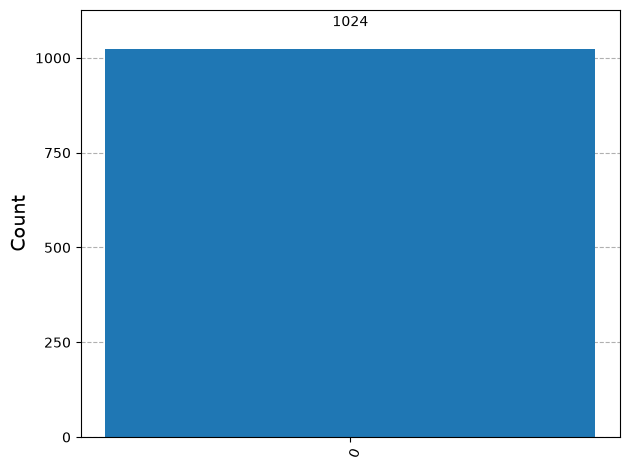

In [51]:
histogram = plot_histogram(counts)
histogram.show()

In [52]:
circuit.remove_final_measurements(inplace=True)
from qiskit.quantum_info import Statevector
statevector = Statevector.from_instruction(circuit)
array_to_latex(statevector, prefix="\\text{Statevector} = ")

<IPython.core.display.Latex object>

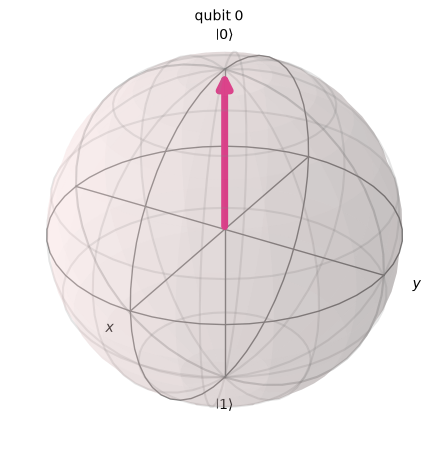

In [53]:
blochsphere =plot_bloch_multivector(statevector)
blochsphere.show()